# Figure S6b — Axodendritic synapse distance to the nearest axon tip

Cumulative distribution of the **cable-length (path) distance from each axodendritic
synapse to the nearest distal axon tip**, one curve per sensory neuron subtype.

The grey dashed curve is the reference: the fraction of total axonal cable lying within a
given distance of a tip, with every skeleton edge weighted by its physical length. Synapse
curves far above it mean synapses concentrate at terminals rather than spreading evenly
along the arbor.

**Aggregation.** One CDF is computed per neuron and interpolated onto a shared grid; the
plotted curve is the **mean across neurons** of a subtype — not a pool of all synapses.
This weights each neuron equally regardless of how many synapses it has.

**Input.** `../data/meshwork_h5/*.h5` — `pcg_skel.pcg_meshwork` exports carrying the
level-2 skeleton plus synapses from the CAVE `sensory_neuron_synapses` table. Subtype per
file comes from `../data/meshwork_h5_subtypes.csv`. **Runs offline — no CAVE access.**

n = 10 axons per subtype (80 files).


In [15]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.size"] = 6

CM = 1 / 2.54


In [16]:
# Internal tag -> published label, and the Figure 3 / S6 colour scheme.
SUBTYPE_LABELS = {
    "ab-ltmr":  "Aβ-LTMR",
    "adltmr":   "Aδ-LTMR",
    "cltmr":    "C-LTMR",
    "mrgd":     "C-HTMR/Heat (MrgprD,MrgprA3,MrgprB4)",
    "sst":      "C-HTMR/Heat (SST)",
    "ad-htmr":  "Aδ-HTMR",
    "c-htmr-p": "Peptidergic C-nociceptor",
    "C-COLD":   "C-Cold",
}

PALETTE = {
    "Aβ-LTMR":                              "#556B2F",
    "Aδ-LTMR":                              "#00A86B",
    "C-LTMR":                               "#BCEBCB",
    "C-HTMR/Heat (MrgprD,MrgprA3,MrgprB4)": "#b23aee",
    "C-HTMR/Heat (SST)":                    "#ffbbff",
    "Aδ-HTMR":                              "#ff4040",
    "Peptidergic C-nociceptor":             "#ffee00",
    "C-Cold":                               "#00bfff",
}

SUBTYPE_ORDER = ["ab-ltmr", "adltmr", "cltmr", "mrgd", "sst",
                 "ad-htmr", "c-htmr-p", "C-COLD"]


In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
from meshparty import meshwork

H5_DIR = Path("../data/meshwork_h5")
SUBTYPE_CSV = Path("../data/meshwork_h5_subtypes.csv")
NM_TO_UM = 1e-3


def load(coord, subdir=""):
    """Load one meshwork .h5 by its 'x_y_z' coordinate string."""
    return meshwork.load_meshwork(H5_DIR / subdir / f"{coord}.h5")


def syn_indices(neuron):
    """Mesh indices of axodendritic and axoaxonic synapses.

    The sensory neuron is the reference cell in these meshwork files, so
    `pre_syn` = synapses it makes onto dendrites (axodendritic) and
    `post_syn` = synapses made onto it (axoaxonic).
    """
    pre = getattr(neuron.anno, "pre_syn", None)
    post = getattr(neuron.anno, "post_syn", None)
    return (np.asarray([] if pre is None else pre.mesh_index, dtype=int),
            np.asarray([] if post is None else post.mesh_index, dtype=int))


def distance_to_tips_um(neuron, idx):
    """Path distance (µm) from each synapse to its nearest axon tip."""
    tips = neuron.end_points
    if len(idx) == 0 or len(tips) == 0:
        return np.array([])
    return np.min(neuron.distance_between(idx, tips), axis=1) * NM_TO_UM


In [18]:
N_POINTS = 1000


def per_neuron_cdf(values_um, x_vals):
    """Empirical CDF of one neuron's synapses, interpolated onto a shared grid."""
    v = np.asarray(values_um, float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return None
    v = np.clip(v, None, x_vals[-1])
    xs = np.sort(v)
    ys = np.arange(1, xs.size + 1) / xs.size
    return np.interp(x_vals, np.r_[0.0, xs], np.r_[0.0, ys], left=0.0, right=1.0)


def cable_edges_to_tips(neuron):
    """Per skeleton edge: (distance of its midpoint to the nearest tip, its length).

    This is the grey reference curve. Each edge is weighted by the physical cable
    length it represents, so the curve answers "what fraction of the arbor lies
    within X µm of a tip?" -- the null expectation if synapses were spread evenly.
    """
    sk = neuron.skeleton
    verts = np.asarray(sk.vertices, float)
    edges = np.asarray(sk.edges, int)
    if len(edges) == 0:
        return np.array([]), np.array([])

    mesh_idx = np.asarray(sk.mesh_index)
    v_to_tip = np.min(neuron.distance_between(mesh_idx, neuron.end_points), axis=1)

    length = np.linalg.norm(verts[edges[:, 1]] - verts[edges[:, 0]], axis=1)
    midpoint = np.minimum(v_to_tip[edges[:, 0]], v_to_tip[edges[:, 1]]) + 0.5 * length
    return midpoint, length


def per_neuron_cable_cdf(dist_nm, length_nm, x_vals):
    """Cable-length-weighted CDF for one neuron."""
    d = np.asarray(dist_nm, float)
    w = np.asarray(length_nm, float)
    ok = np.isfinite(d) & np.isfinite(w) & (w > 0)
    if not ok.any():
        return None
    d, w = np.clip(d[ok] * NM_TO_UM, None, x_vals[-1]), w[ok] * NM_TO_UM
    o = np.argsort(d)
    cum = np.cumsum(w[o])
    return np.interp(x_vals, np.r_[0.0, d[o]], np.r_[0.0, cum / cum[-1]],
                     left=0.0, right=1.0)


In [19]:
CAP_UM = 200.0
x_vals = np.linspace(0, CAP_UM, N_POINTS)

subtypes = pd.read_csv(SUBTYPE_CSV)
subtypes["subtype"] = subtypes.subtype.str.strip()   # CAVE tags carry trailing spaces
subtypes["coord"] = subtypes.coord.astype(str).str.strip()
print(subtypes.subtype.value_counts().reindex(SUBTYPE_ORDER).to_string())

syn_cdfs = {t: [] for t in SUBTYPE_ORDER}
cable_cdfs = []

for coord, tag in zip(subtypes.coord, subtypes.subtype):
    neuron = load(coord)
    pre_idx, _ = syn_indices(neuron)

    c = per_neuron_cdf(distance_to_tips_um(neuron, pre_idx), x_vals)
    if c is not None:
        syn_cdfs[tag].append(c)

    d_nm, len_nm = cable_edges_to_tips(neuron)
    cc = per_neuron_cable_cdf(d_nm, len_nm, x_vals)
    if cc is not None:
        cable_cdfs.append(cc)

print(f"\nneurons contributing a synapse CDF: "
      f"{sum(len(v) for v in syn_cdfs.values())}, cable CDFs: {len(cable_cdfs)}")


subtype
ab-ltmr     10
adltmr      10
cltmr       10
mrgd        10
sst         10
ad-htmr     10
c-htmr-p    10
C-COLD      10

neurons contributing a synapse CDF: 80, cable CDFs: 80


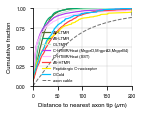

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.0 * CM, 4.0 * CM))

for tag in SUBTYPE_ORDER:
    if not syn_cdfs[tag]:
        continue
    label = SUBTYPE_LABELS[tag]
    ax.plot(x_vals, np.vstack(syn_cdfs[tag]).mean(axis=0),
            color=PALETTE[label], lw=1.2, label=label)

mean_cable = np.vstack(cable_cdfs).mean(axis=0)
ax.plot(x_vals, mean_cable, color="0.45", lw=1.0, ls="--", label="axon cable")

ax.set_xlim(0, CAP_UM)
ax.set_ylim(0, 1.01)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xlabel("Distance to nearest axon tip (µm)", fontsize=6)
ax.set_ylabel("Cumulative fraction", fontsize=6)
ax.tick_params(labelsize=5)
ax.grid(True, lw=0.3)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(fontsize=4, frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig("figureS6b_axodendritic_distance_to_axon_tip.svg", format="svg", dpi=300)
plt.show()


In [21]:
# Fraction within 25 and 50 µm of a tip (the values quoted in the Results).
print(f"{'':40s}{'<=25 µm':>10s}{'<=50 µm':>10s}")
for tag in SUBTYPE_ORDER:
    if not syn_cdfs[tag]:
        continue
    m = np.vstack(syn_cdfs[tag]).mean(axis=0)
    f25, f50 = np.interp([25, 50], x_vals, m)
    print(f"{SUBTYPE_LABELS[tag]:40s}{f25:9.1%}{f50:10.1%}")
f25, f50 = np.interp([25, 50], x_vals, mean_cable)
print(f"{'axon cable (reference)':40s}{f25:9.1%}{f50:10.1%}")


                                           <=25 µm   <=50 µm
Aβ-LTMR                                     72.4%     95.2%
Aδ-LTMR                                     80.3%     95.8%
C-LTMR                                      75.1%     91.5%
C-HTMR/Heat (MrgprD,MrgprA3,MrgprB4)        77.7%     90.1%
C-HTMR/Heat (SST)                           74.2%     85.6%
Aδ-HTMR                                     47.3%     70.8%
Peptidergic C-nociceptor                    53.5%     69.2%
C-Cold                                      53.8%     78.3%
axon cable (reference)                      21.1%     41.7%
